# Merge de los datos de transaccion

In [83]:
import pandas as pd
import numpy as np
import json
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

In [84]:
# =============================================================================
# CONSTRUCCIÓN DEL CSV ENRIQUECIDO DE CLIENTES
# De: hey_clientes.csv + hey_productos.csv + hey_transacciones.csv
# A:  hey_clientes_perfil_completo.csv
# =============================================================================
#
# Lógica general:
#   1. Cargar los 3 CSVs originales
#   2. Agregar hey_productos por user_id → métricas de productos
#   3. Agregar hey_transacciones por user_id → métricas de comportamiento
#   4. Calcular variables de perfil (producto principal, categoría top, etc.)
#   5. Hacer join de todo contra hey_clientes (left join para conservar todos)
#   6. Exportar el CSV final
# =============================================================================

import pandas as pd
import numpy as np

# =============================================================================
# PASO 1 — CARGA DE LOS 3 CSVS ORIGINALES
# =============================================================================

clientes     = pd.read_csv("data/dataset_transacciones/hey_clientes.csv")
productos    = pd.read_csv("data/dataset_transacciones/hey_productos.csv")
transacciones = pd.read_csv("data/dataset_transacciones/hey_transacciones.csv")

print(f"[1] Clientes:      {len(clientes):>6,} filas × {len(clientes.columns)} cols")
print(f"    Productos:     {len(productos):>6,} filas × {len(productos.columns)} cols")
print(f"    Transacciones: {len(transacciones):>6,} filas × {len(transacciones.columns)} cols")


# =============================================================================
# PASO 2 — AGREGADOS DE PRODUCTOS POR USUARIO
# =============================================================================
# Queremos saber, para cada cliente:
#   · Cuántos productos tiene en total
#   · Qué tipos de productos tiene (lista)
#   · Cuántos están activos
#   · Suma de límites de crédito
#   · Saldo total actual
#   · Utilización de crédito promedio

prod_agg = (
    productos
    .groupby('user_id')
    .agg(
        total_productos      = ('producto_id',    'count'),
        tipos_producto       = ('tipo_producto',  lambda x: ', '.join(sorted(x.unique()))),
        productos_activos    = ('estatus',        lambda x: (x == 'activo').sum()),
        limite_credito_total = ('limite_credito', 'sum'),
        saldo_total          = ('saldo_actual',   'sum'),
        utilizacion_promedio = ('utilizacion_pct','mean'),
    )
    .reset_index()
)

print(f"\n[2] Agregados de productos: {len(prod_agg):,} usuarios")


# =============================================================================
# PASO 3 — AGREGADOS DE TRANSACCIONES POR USUARIO
# =============================================================================
# Métricas generales de comportamiento transaccional:
#   · Volumen total de transacciones
#   · Monto total y promedio
#   · Cashback acumulado
#   · Número de transacciones internacionales
#   · Diversidad de categorías usadas
#   · Lista de canales utilizados

txn_agg = (
    transacciones
    .groupby('user_id')
    .agg(
        total_transacciones = ('transaccion_id', 'count'),
        monto_total_txn     = ('monto',          'sum'),
        monto_promedio_txn  = ('monto',          'mean'),
        cashback_total      = ('cashback_generado', 'sum'),
        txn_internacionales = ('es_internacional',  'sum'),
        categorias_unicas   = ('categoria_mcc',  lambda x: x.nunique()),
        canales_usados      = ('canal',          lambda x: ', '.join(sorted(x.unique()))),
    )
    .reset_index()
)

print(f"[3] Agregados de transacciones: {len(txn_agg):,} usuarios")


# =============================================================================
# PASO 4 — VARIABLES DE PERFIL CONDUCTUAL
# =============================================================================
# Estas columnas responden "¿cuál es el comportamiento DOMINANTE del cliente?"
# en lugar de solo listar todo lo que hace. Son las más útiles para perfilado.
#
# Filtramos solo transacciones completadas para medir comportamiento real,
# descartando intentos fallidos o rechazados.

txn_ok = transacciones[transacciones['estatus'] == 'completada'].copy()

# --- 4a. Producto principal ---
# El producto con más transacciones completadas por usuario.
# Responde: ¿qué producto usa más en la práctica?

prod_principal = (
    txn_ok
    .groupby(['user_id', 'producto_id'])
    .size()
    .reset_index(name='n_txn')
    .sort_values('n_txn', ascending=False)
    .drop_duplicates('user_id')                          # quedarse con el top 1
    [['user_id', 'producto_id']]
    .rename(columns={'producto_id': 'producto_principal_id'})
)
# Join para traer el tipo de producto desde hey_productos
prod_principal = prod_principal.merge(
    productos[['producto_id', 'tipo_producto']],
    left_on  = 'producto_principal_id',
    right_on = 'producto_id',
    how      = 'left'
)[['user_id', 'tipo_producto']].rename(columns={'tipo_producto': 'tipo_producto_principal'})

# --- 4b. Categoría MCC principal ---
# La categoría de gasto más frecuente.
# Se excluye 'transferencia' porque es ruido: no representa un gasto real,
# solo movimientos de dinero entre cuentas.

txn_cat = txn_ok[txn_ok['categoria_mcc'] != 'transferencia']

cat_principal = (
    txn_cat
    .groupby(['user_id', 'categoria_mcc'])
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('user_id')
    [['user_id', 'categoria_mcc']]
    .rename(columns={'categoria_mcc': 'categoria_mcc_principal'})
)

# --- 4c. Canal principal real ---
# El canal más usado según transacciones (puede diferir del campo
# 'preferencia_canal' declarado en el perfil del cliente).

canal_principal = (
    txn_ok
    .groupby(['user_id', 'canal'])
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('user_id')
    [['user_id', 'canal']]
    .rename(columns={'canal': 'canal_principal_real'})
)

# --- 4d. Tipo de operación principal ---
# La operación más frecuente: compra, retiro, transferencia, pago de servicio, etc.

op_principal = (
    txn_ok
    .groupby(['user_id', 'tipo_operacion'])
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('user_id')
    [['user_id', 'tipo_operacion']]
    .rename(columns={'tipo_operacion': 'tipo_operacion_principal'})
)

print(f"[4] Variables de perfil conductual calculadas")


# =============================================================================
# PASO 5 — JOIN COMPLETO CONTRA EL CSV DE CLIENTES
# =============================================================================
# Usamos left join en todos los casos para conservar los 15,025 clientes
# originales, incluso si alguno no tiene productos o transacciones registradas
# (en ese caso sus columnas nuevas quedarán como NaN).

df_final = clientes.copy()

for nombre, tabla in [
    ('prod_agg',       prod_agg),
    ('txn_agg',        txn_agg),
    ('prod_principal', prod_principal),
    ('cat_principal',  cat_principal),
    ('canal_principal',canal_principal),
    ('op_principal',   op_principal),
]:
    df_final = df_final.merge(tabla, on='user_id', how='left')
    print(f"    + {nombre}: ahora {len(df_final.columns)} columnas")

print(f"\n[5] Dataset final: {len(df_final):,} filas × {len(df_final.columns)} columnas")


# =============================================================================
# PASO 6 — VALIDACIÓN RÁPIDA
# =============================================================================

nulos_pct = (df_final.isnull().sum() / len(df_final) * 100).round(1)
nulos_relevantes = nulos_pct[nulos_pct > 0]

if len(nulos_relevantes) > 0:
    print(f"\n[6] Columnas con nulos (clientes sin actividad en esa dimensión):")
    for col, pct in nulos_relevantes.items():
        print(f"    {col}: {pct}%")
else:
    print(f"\n[6] Sin nulos — todos los clientes tienen datos completos ✓")

print(f"\n    Columnas originales de clientes: {len(clientes.columns)}")
print(f"    Columnas nuevas agregadas:       {len(df_final.columns) - len(clientes.columns)}")
print(f"    Total columnas finales:          {len(df_final.columns)}")
print(f"\n    Distribución por tipo de columna nueva:")
print(f"    · Métricas de productos (agg):      6 columnas")
print(f"    · Métricas de transacciones (agg):  7 columnas")
print(f"    · Variables de perfil conductual:   4 columnas")

[1] Clientes:      15,025 filas × 22 cols
    Productos:     38,909 filas × 13 cols
    Transacciones: 802,384 filas × 22 cols

[2] Agregados de productos: 15,025 usuarios
[3] Agregados de transacciones: 15,025 usuarios
[4] Variables de perfil conductual calculadas
    + prod_agg: ahora 28 columnas
    + txn_agg: ahora 35 columnas
    + prod_principal: ahora 36 columnas
    + cat_principal: ahora 37 columnas
    + canal_principal: ahora 38 columnas
    + op_principal: ahora 39 columnas

[5] Dataset final: 15,025 filas × 39 columnas

[6] Columnas con nulos (clientes sin actividad en esa dimensión):
    estado: 2.9%
    ciudad: 2.9%
    satisfaccion_1_10: 5.0%
    utilizacion_promedio: 27.0%
    categoria_mcc_principal: 0.1%

    Columnas originales de clientes: 22
    Columnas nuevas agregadas:       17
    Total columnas finales:          39

    Distribución por tipo de columna nueva:
    · Métricas de productos (agg):      6 columnas
    · Métricas de transacciones (agg):  7 columnas

In [85]:
df_final

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,monto_total_txn,monto_promedio_txn,cashback_total,txn_internacionales,categorias_unicas,canales_usados,tipo_producto_principal,categoria_mcc_principal,canal_principal_real,tipo_operacion_principal
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,119570.59,2135.189107,122.33,2,7,"app_android, app_huawei, app_ios, codi, oxxo, ...",cuenta_debito,servicios_digitales,app_android,compra
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,212722.67,2874.630676,147.08,1,7,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_android,compra
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,190801.09,2415.203671,165.43,4,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,pos_fisico,compra
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,580113.74,8789.602121,0.00,2,10,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,supermercado,app_android,compra
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,190277.30,2045.992473,162.99,1,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_ios,compra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15020,USR-15021,56,M,Nuevo León,Monterrey,Secundaria,Empleado,40000,1145,True,...,565510.87,9584.930000,428.84,5,10,"app_android, app_huawei, app_ios, cajero_exter...",cuenta_debito,supermercado,app_android,compra
15021,USR-15022,34,M,Ciudad de México,CDMX - Miguel Hidalgo,Licenciatura,Empleado,13500,1652,False,...,306412.43,5023.154590,0.00,5,9,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,gobierno,pos_fisico,compra
15022,USR-15023,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empleado,19500,671,True,...,230110.76,4183.832000,79.30,1,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_ios,compra
15023,USR-15024,27,M,Ciudad de México,CDMX - Benito Juárez,Licenciatura,Empleado,4500,434,False,...,55102.40,4238.646154,0.00,1,4,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,restaurante,app_ios,compra


In [86]:
df_final.isnull().sum()

user_id                        0
edad                           0
sexo                           0
estado                       432
ciudad                       432
nivel_educativo                0
ocupacion                      0
ingreso_mensual_mxn            0
antiguedad_dias                0
es_hey_pro                     0
nomina_domiciliada             0
canal_apertura                 0
score_buro                     0
dias_desde_ultimo_login        0
preferencia_canal              0
satisfaccion_1_10            751
recibe_remesas                 0
usa_hey_shop                   0
idioma_preferido               0
tiene_seguro                   0
num_productos_activos          0
patron_uso_atipico             0
total_productos                0
tipos_producto                 0
productos_activos              0
limite_credito_total           0
saldo_total                    0
utilizacion_promedio        4055
total_transacciones            0
monto_total_txn                0
monto_prom

In [87]:
# Separar features por tipo
numericas = [
    'edad',
    'ingreso_mensual_mxn',
    'antiguedad_dias',
    'score_buro',
    'dias_desde_ultimo_login',
    'satisfaccion_1_10',
    'num_productos_activos',
    'limite_credito_total',
    'saldo_total',
    'utilizacion_promedio',
    'total_transacciones',
    'monto_total_txn',
    'monto_promedio_txn',
    'cashback_total',
    'txn_internacionales',
    'categorias_unicas',
]
 
binarias = [
    'es_hey_pro',
    'nomina_domiciliada',
    'recibe_remesas',
    'usa_hey_shop',
    'tiene_seguro',
    'patron_uso_atipico',
]
 
categoricas = [
    'sexo',
    'nivel_educativo',
    'ocupacion',
    'canal_apertura',
    'preferencia_canal',
    'idioma_preferido',
    'tipo_producto_principal',
    'categoria_mcc_principal',
    'canal_principal_real',
    'tipo_operacion_principal',
]

# Preprocesamiento
dm = df_final[numericas + binarias + categoricas].copy()

dm[numericas] = dm[numericas].fillna(dm[numericas].median())
dm[binarias]  = dm[binarias].fillna(False).astype(int)

for col in categoricas:
    dm[col] = dm[col].fillna(dm[col].mode()[0])
    le = LabelEncoder()
    dm[col] = le.fit_transform(dm[col].astype(str))

# Escalar variables numéricas
scaler = StandardScaler()
dm[numericas] = scaler.fit_transform(dm[numericas])
 
X = dm.values.astype(np.float32)

In [88]:
# =============================================================================
# PASO 4 — REDUCCIÓN DIMENSIONAL
# =============================================================================
# Objetivo: eliminar ruido y correlaciones antes de clusterizar.
# Con 32 features muchas son redundantes (ej. monto_total_txn ≈ txn * monto_prom).
#
# Opción A — PCA (usado aquí por limitaciones de RAM):
#   Rápido, determinista, funciona bien con variables numéricas ya escaladas.
#   Captura estructura lineal. 10 componentes = 80.1% de varianza explicada.
#
# Opción B — UMAP (recomendado en producción):
#   Preserva estructura no-lineal y clusters locales. Mejor para datos mixtos.
#   Requiere más memoria (~4-8 GB para 15k filas × 32 dims).
#
# Descomenta el bloque UMAP si tu entorno tiene suficiente RAM:
 
# --- UMAP (producción) ---
# reducer = umap.UMAP(
#     n_components=10,
#     n_neighbors=30,   # vecinos para construir el grafo; más = más global
#     min_dist=0.1,     # qué tan juntos pueden quedar puntos en el embedding
#     metric='euclidean',
#     random_state=42
# )
# embedding = reducer.fit_transform(X)
# --- PCA (este entorno) ---
pca = PCA(n_components=10, random_state=42)
embedding = pca.fit_transform(X)
var_explicada = pca.explained_variance_ratio_.sum() * 100

In [89]:
import plotly.express as px

components = list(range(1, len(pca.explained_variance_ratio_)+1))
variance_ratio = pca.explained_variance_ratio_

fig = px.line(
    x=components,
    y=variance_ratio,
    markers = True,
    labels={'x': 'Principal Component', 'y': 'Explained Variance Ratio'},
    title='Scree Plot'
)
fig.show()

In [90]:
# =============================================================================
# PASO 5 — BÚSQUEDA DEL K ÓPTIMO (SILHOUETTE SCORE + MÉTODO DEL CODO)
# =============================================================================
# Silhouette score: mide qué tan bien separado está cada punto de su cluster
# vs. el cluster más cercano. Rango [-1, 1]. Más alto = mejor separación.
#
# Método del codo (inertia): suma de distancias cuadradas al centroide.
# Buscamos el punto donde la curva "dobla" y deja de bajar rápidamente.
#
# sample_size en silhouette_score: calcular con todos los puntos es O(n²).
# Una muestra de 5,000 es estadísticamente representativa para 15k registros.
 
print("[5] Evaluando k=2 a k=8:")
sil_scores = {}
inertias   = {}
 
for k in range(2, 9):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embedding)
 
    sil = silhouette_score(embedding, labels, sample_size=5000, random_state=42)
    sil_scores[k] = round(float(sil), 4)
    inertias[k]   = round(float(km.inertia_), 2)
 
    print(f"    k={k}: silhouette={sil:.4f}  inertia={km.inertia_:,.0f}")
 
k_matematico = max(sil_scores, key=sil_scores.get)
print(f"\n    K matemáticamente óptimo: {k_matematico} "
      f"(silhouette={sil_scores[k_matematico]})")
 

[5] Evaluando k=2 a k=8:
    k=2: silhouette=0.3122  inertia=283,454
    k=3: silhouette=0.2397  inertia=247,888
    k=4: silhouette=0.2267  inertia=217,462
    k=5: silhouette=0.2379  inertia=194,896
    k=6: silhouette=0.2433  inertia=181,698
    k=7: silhouette=0.2296  inertia=168,764
    k=8: silhouette=0.2162  inertia=160,325

    K matemáticamente óptimo: 2 (silhouette=0.3122)


In [91]:
# =============================================================================
# PASO 6 — MODELO FINAL
# =============================================================================
# Usamos k=5 en lugar del k=2 matemáticamente óptimo.
# Razón: con k=2 los segmentos son "alto score" vs "bajo score", lo cual
# es verdad pero poco accionable. Con k=5 obtenemos arquetipos diferenciados
# en ingreso, comportamiento digital, antigüedad y productos activos.
# Esta es una decisión deliberada de utilidad de negocio sobre pureza estadística.
#
# Regla práctica: en perfilado de clientes bancarios, k entre 4 y 7 suele
# dar el mejor balance entre interpretabilidad y granularidad.
 
K_ELEGIDO = 5
 
km_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df_final['cluster'] = km_final.fit_predict(embedding)

mapping ={
    0: 'Jóvenes digitales',
    1: 'Cliente poco activo',
    2: 'Cliente premium',
    3: 'Empleado de nómina domiciliada',
    4: 'Profesionalista de alto ingreso',
}

df_final['cluster'] = df_final['cluster'].map(mapping)
 
print(f"\n[6] Modelo final K-Means con k={K_ELEGIDO}:")
print(df_final['cluster'].value_counts().sort_index().to_string())
 


[6] Modelo final K-Means con k=5:
cluster
Cliente poco activo                1363
Cliente premium                    3192
Empleado de nómina domiciliada     3441
Jóvenes digitales                  4937
Profesionalista de alto ingreso    2092


In [92]:
# =============================================================================
# PASO 7 — UMAP 2D PARA VISUALIZACIÓN
# =============================================================================
# El UMAP 10D para clustering requiere demasiada RAM con el dataset completo.
# Para visualización usamos una muestra de 3,000 registros con UMAP 2D,
# que sí es manejable y da una representación visual fiel de los clusters.
 
print("\n[7] Generando UMAP 2D para visualización (muestra 3,000 registros)...")
idx_sample = np.random.RandomState(42).choice(len(X), size=3000, replace=False)
X_sample   = X[idx_sample]
 
reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
emb_2d     = reducer_2d.fit_transform(X_sample)
 
# Guardar coordenadas 2D en el dataframe (NaN para los no muestreados)
df_final['umap_x'] = np.nan
df_final['umap_y'] = np.nan
df_final.loc[idx_sample, 'umap_x'] = emb_2d[:, 0]
df_final.loc[idx_sample, 'umap_y'] = emb_2d[:, 1]
 
print("    UMAP 2D OK")
 


[7] Generando UMAP 2D para visualización (muestra 3,000 registros)...


c:\Users\ludio\Datathon-2026-Wicho\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


    UMAP 2D OK


In [93]:
# =============================================================================
# PASO 9 — PERFIL DE CADA CLUSTER
# =============================================================================
# Calculamos estadísticas descriptivas por cluster para poder nombrar e
# interpretar cada segmento de negocio.
 
print("\n[9] Perfil de clusters:\n")
 
perfil = df_final.groupby('cluster').agg(
    n_clientes       = ('user_id',                'count'),
    edad_prom        = ('edad',                   'mean'),
    ingreso_prom     = ('ingreso_mensual_mxn',    'mean'),
    score_buro_prom  = ('score_buro',             'mean'),
    antiguedad_prom  = ('antiguedad_dias',        'mean'),
    txn_prom         = ('total_transacciones',    'mean'),
    monto_prom       = ('monto_promedio_txn',     'mean'),
    monto_total_prom = ('monto_total_txn',        'mean'),
    saldo_prom       = ('saldo_total',            'mean'),
    utilizacion_prom = ('utilizacion_promedio',   'mean'),
    pct_hey_pro      = ('es_hey_pro',             'mean'),
    pct_nomina       = ('nomina_domiciliada',     'mean'),
    pct_seguro       = ('tiene_seguro',           'mean'),
    pct_remesas      = ('recibe_remesas',         'mean'),
    categoria_top    = ('categoria_mcc_principal', lambda x: x.mode()[0]),
    canal_top        = ('canal_principal_real',   lambda x: x.mode()[0]),
    producto_top     = ('tipo_producto_principal', lambda x: x.mode()[0]),
    operacion_top    = ('tipo_operacion_principal', lambda x: x.mode()[0]),
).round(2)
 
print(perfil.to_string())


[9] Perfil de clusters:

                                 n_clientes  edad_prom  ingreso_prom  score_buro_prom  antiguedad_prom  txn_prom  monto_prom  monto_total_prom  saldo_prom  utilizacion_prom  pct_hey_pro  pct_nomina  pct_seguro  pct_remesas        categoria_top canal_top   producto_top operacion_top
cluster                                                                                                                                                                                                                                                                                   
Cliente poco activo                    1363      40.45      19958.91           542.18           893.42     10.65     4426.63          48236.17    45433.84              0.29         0.09        0.12        0.19         0.09             gobierno   app_ios  cuenta_debito        compra
Cliente premium                        3192      40.92      45066.42           723.10           956.53     60.66    10167.14 

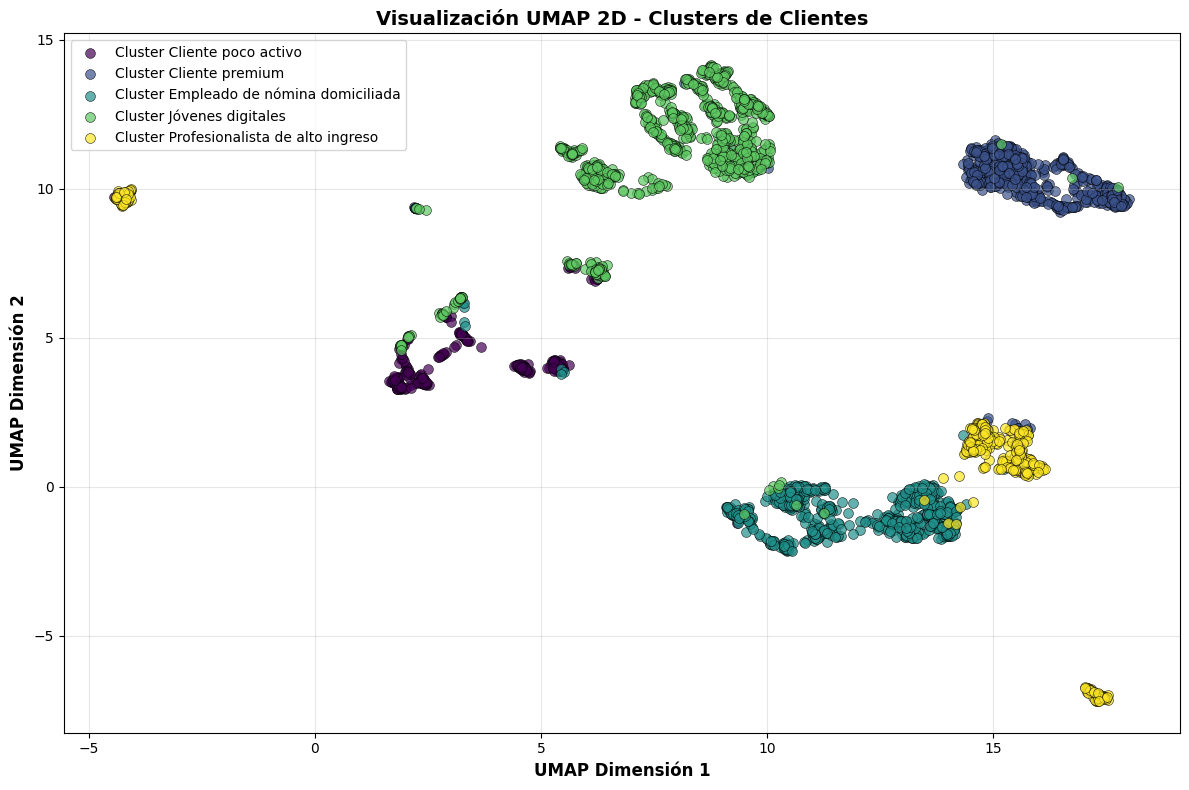


✅ Visualización UMAP 2D generada para 3000 registros muestreados
📊 Distribución por cluster:
cluster
Cliente poco activo                280
Cliente premium                    610
Empleado de nómina domiciliada     712
Jóvenes digitales                  985
Profesionalista de alto ingreso    413
Name: count, dtype: int64


In [94]:
# =============================================================================
# VISUALIZACIÓN UMAP 2D CON CLUSTERS
# =============================================================================
# Graficar los embeddings 2D coloreados por cluster para ver la separación

import matplotlib.pyplot as plt

# Filtrar solo los puntos que tienen coordenadas UMAP (muestra de 3000)
df_plot = df_final.dropna(subset=['umap_x', 'umap_y']).copy()

# Crear figura
fig, ax = plt.subplots(figsize=(12, 8))

# Plotear cada cluster con color diferente
clusters = df_plot['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

for i, cluster_id in enumerate(sorted(clusters)):
    mask = df_plot['cluster'] == cluster_id
    ax.scatter(
        df_plot[mask]['umap_x'],
        df_plot[mask]['umap_y'],
        c=[colors[i]],
        label=f'Cluster {cluster_id}',
        s=50,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.5
    )

ax.set_xlabel('UMAP Dimensión 1', fontsize=12, fontweight='bold')
ax.set_ylabel('UMAP Dimensión 2', fontsize=12, fontweight='bold')
ax.set_title('Visualización UMAP 2D - Clusters de Clientes', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Visualización UMAP 2D generada para {len(df_plot)} registros muestreados")
print(f"📊 Distribución por cluster:")
print(df_plot['cluster'].value_counts().sort_index())

In [95]:
df_final

,user_id,edad,sexo,estado,ciudad,nivel_educativo,ocupacion,ingreso_mensual_mxn,antiguedad_dias,es_hey_pro,...,txn_internacionales,categorias_unicas,canales_usados,tipo_producto_principal,categoria_mcc_principal,canal_principal_real,tipo_operacion_principal,cluster,umap_x,umap_y
0,USR-00001,21,M,Ciudad de México,CDMX - Benito Juárez,Preparatoria,Empleado,24500,1554,True,...,2,7,"app_android, app_huawei, app_ios, codi, oxxo, ...",cuenta_debito,servicios_digitales,app_android,compra,Jóvenes digitales,NaN,NaN
1,USR-00002,18,M,Jalisco,Puerto Vallarta,Preparatoria,Estudiante,19000,1410,True,...,1,7,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_android,compra,Jóvenes digitales,NaN,NaN
2,USR-00003,23,H,Chihuahua,Cuauhtémoc,Licenciatura,Estudiante,14000,1174,True,...,4,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,pos_fisico,compra,Jóvenes digitales,NaN,NaN
3,USR-00004,32,SE,Nuevo León,Guadalupe,Posgrado,Empleado,61000,1168,False,...,2,10,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,supermercado,app_android,compra,Cliente premium,15.142851,10.203487
4,USR-00005,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empresario,27000,816,True,...,1,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_ios,compra,Jóvenes digitales,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15020,USR-15021,56,M,Nuevo León,Monterrey,Secundaria,Empleado,40000,1145,True,...,5,10,"app_android, app_huawei, app_ios, cajero_exter...",cuenta_debito,supermercado,app_android,compra,Cliente premium,NaN,NaN
15021,USR-15022,34,M,Ciudad de México,CDMX - Miguel Hidalgo,Licenciatura,Empleado,13500,1652,False,...,5,9,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,gobierno,pos_fisico,compra,Empleado de nómina domiciliada,NaN,NaN
15022,USR-15023,26,M,Ciudad de México,CDMX - Cuauhtémoc,Preparatoria,Empleado,19500,671,True,...,1,8,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,servicios_digitales,app_ios,compra,Jóvenes digitales,NaN,NaN
15023,USR-15024,27,M,Ciudad de México,CDMX - Benito Juárez,Licenciatura,Empleado,4500,434,False,...,1,4,"app_android, app_huawei, app_ios, cajero_banre...",cuenta_debito,restaurante,app_ios,compra,Cliente poco activo,5.264419,3.977504
